<a href="https://colab.research.google.com/github/shravanthc/Student-performance-prediction/blob/main/student.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [25]:
from google.colab import files
uploaded = files.upload()

Saving Maths.csv to Maths.csv


In [4]:
import os
print(os.listdir())

['.config', 'Students_performance.csv', 'Students_performance (1).csv', 'sample_data']


In [10]:
!pip install pandas numpy


In [11]:
import pandas as pd
import numpy as np

print("Pandas imported successfully!")


Pandas imported successfully!


In [12]:
import os
print(os.listdir())

['.config', 'Students_performance.csv', 'Students_performance (1).csv', 'sample_data']


In [28]:
!pip install openpyxl

In [29]:
import pandas as pd

df = pd.read_excel("Maths.csv")
df.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


In [32]:
df.columns

Index(['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu',
       'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime',
       'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery',
       'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc',
       'Walc', 'health', 'absences', 'G1', 'G2', 'G3'],
      dtype='object')

In [35]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

categorical_columns = ['school', 'sex', 'address', 'famsize', 'Pstatus',
                       'Mjob', 'Fjob', 'reason', 'guardian',
                       'schoolsup', 'famsup', 'paid', 'activities',
                       'nursery', 'higher', 'internet', 'romantic']

for col in categorical_columns:
    df[col] = le.fit_transform(df[col])

In [36]:
X = df.drop("G3", axis=1)
y = df["G3"]

In [37]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [38]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train, y_train)

LinearRegression()

In [39]:
predictions = model.predict(X_test)

print(predictions[:10])

[ 8.46783459  6.70795723 12.57434548 15.56785689  5.79072084 11.77343461
 12.02196591  6.95890668 -2.52469484  9.39095076]


In [40]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("Mean Absolute Error:", mean_absolute_error(y_test, predictions))
print("Mean Squared Error:", mean_squared_error(y_test, predictions))
print("R2 Score:", r2_score(y_test, predictions))

Mean Absolute Error: 1.14782973177179
Mean Squared Error: 2.915553523725184
R2 Score: 0.8552794621178021


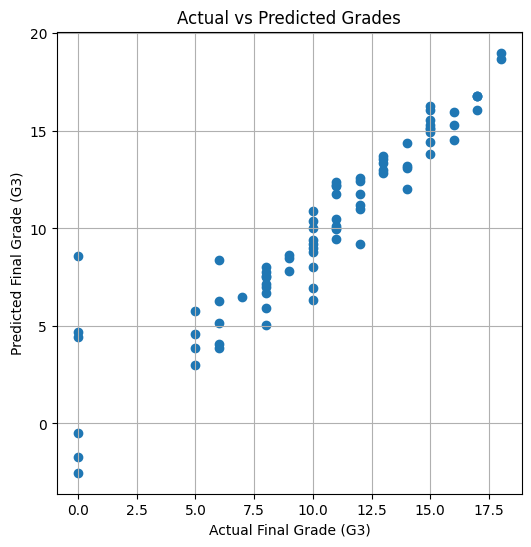

In [41]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))
plt.scatter(y_test, predictions)
plt.xlabel("Actual Final Grade (G3)")
plt.ylabel("Predicted Final Grade (G3)")
plt.title("Actual vs Predicted Grades")
plt.grid(True)
plt.show()

In [42]:
sample = X.iloc[[0]]

prediction = model.predict(sample)

print("Predicted Final Grade:", prediction[0])

Predicted Final Grade: 5.16410823914791
